In [2]:
import csv
import pandas as pd
import numpy as np
import lifelines
import pickle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from lifelines import CoxPHFitter

In [3]:
# original dataset

In [4]:
df_train = pd.read_csv('df_train_cph5.csv')
df_test = pd.read_csv('df_test_cph5.csv') 

df_final = pd.concat([df_train, df_test], ignore_index=True)

In [5]:
# train model
formula="bs(BMICALC, degree=2, df=3,extrapolation='clip') + bs(HRSLEEP, degree=1, df=2) + bs(STRONGFWK, degree=2, df=2) + bs(ALCDAYSYR, degree=1, df=2) + bs(ALCAMT, degree=2, df=2) + bs(POVERTY, degree=2, df=2) +" + " + ".join(df_train.columns.difference(['TIMETOEVENT', 'MORTSTAT','BMICALC', 'HRSLEEP', 'STRONGFWK', 'ALCDAYSYR', 'ALCAMT', 'POVERTY']))

cph = CoxPHFitter(penalizer=0)
cph.fit(df_train,
        duration_col='TIMETOEVENT', 
        event_col='MORTSTAT',
        formula=formula)

<lifelines.CoxPHFitter: fitted with 82720 total observations, 78101 right-censored observations>

In [ ]:
# adjust BMI

In [6]:
# load the saved x_vals and y_vals from the file
data = np.load('x_y_vals.npz')
# extract x_vals and y_vals
x_vals = data['x_vals']
y_vals = data['y_vals']

# define the interpolation function T
def T(x):
    return np.interp(x, x_vals, y_vals)

In [7]:
# adjust BMI values
df_train_1990 = df_train.copy()
df_test_1990 = df_test.copy()
df_final_1990 = df_final.copy()
train_num = len(df_train_1990)
test_num = len(df_test_1990)

df_train_1990['BMICALC'] = T(df_train['BMICALC'])
df_test_1990['BMICALC'] = T(df_test['BMICALC'])
df_final_1990['BMICALC'] = T(df_final['BMICALC'])

In [8]:
# get ppl that should be adjsuted 
with open('selected_people_hyper_METHOD_II.pkl', 'rb') as f:
    selected_people_hyper = pickle.load(f)
with open('selected_people_diab_METHOD_II.pkl', 'rb') as f:
    selected_people_diab = pickle.load(f)

In [9]:
# make ppl healthy
df_final_1990.loc[df_final_1990.index.isin(selected_people_diab), 'DIABETICEV'] = 1

df_final_1990.loc[
    df_final_1990.index.isin(selected_people_diab) & (df_final_1990['SEX'] == 2), 'FEMALE_HYPERTENEV'] = 0
df_final_1990.loc[
    df_final_1990.index.isin(selected_people_diab) & (df_final_1990['CANCEREV'] == 2), 'CANCEREV_HYPERTENEV'] = 0
df_final_1990.loc[
    df_final_1990.index.isin(selected_people_diab), 'HYPERTENEV\_STRONGFWK'] = 0 

In [10]:
# get adjusted train and test datasets
df_train_1990 = df_final_1990.head(train_num)
df_test_1990 = df_final_1990.tail(test_num)

In [ ]:
# --- predictions ----

In [11]:
# predict the survival function for each individual
probs_train = cph.predict_survival_function(df_train)
probs_test = cph.predict_survival_function(df_test)
probs_final = cph.predict_survival_function(df_final)
probs_train_1990 = cph.predict_survival_function(df_train_1990)
probs_test_1990 = cph.predict_survival_function(df_test_1990)
probs_final_1990 = cph.predict_survival_function(df_final_1990)

# extract 3y survival probabilities
prob_train = np.array(probs_train.iloc[3])
prob_test = np.array(probs_test.iloc[3]) 
prob_final = np.array(probs_final.iloc[3]) 
prob_train_1990 = np.array(probs_train_1990.iloc[3]) 
prob_test_1990 = np.array(probs_test_1990.iloc[3]) 
prob_final_1990 = np.array(probs_final_1990.iloc[3]) 

In [12]:
# --- MSD ---
print(f"final dataset {np.mean((prob_final_1990 - prob_final) ** 2):.6f}")
print(f"training dataset {np.mean((prob_train_1990 - prob_train) ** 2):.6f}")
print(f"test dataset {np.mean((prob_test_1990 - prob_test) ** 2):.6f}")

final dataset 0.000073
training dataset 0.000073
test dataset 0.000070


In [13]:
# --- MAD ---
print(f"final dataset {np.mean(np.abs(prob_final_1990 - prob_final)):.5f}")
print(f"training dataset {np.mean(np.abs(prob_train_1990 - prob_train)):.5f}")
print(f"test dataset {np.mean(np.abs(prob_test_1990 - prob_test)):.5f}")

final dataset 0.00312
training dataset 0.00313
test dataset 0.00308


In [14]:
# --- SGR ---
indicator_final = np.array([1 if p < p_adj else 0 for p, p_adj in zip(prob_final, prob_final_1990)])
print(f"final dataset {np.mean(indicator_final)}")
indicator_train = np.array([1 if p < p_adj else 0 for p, p_adj in zip(prob_train, prob_train_1990)])
print(f"train dataset {np.mean(indicator_train)}")
indicator_test = np.array([1 if p < p_adj else 0 for p, p_adj in zip(prob_test, prob_test_1990)])
print(f"test dataset {np.mean(indicator_test)}")

final dataset 0.20005802707930367
train dataset 0.19968568665377176
test dataset 0.20154738878143133


In [15]:
# --- SLR ---
indicator_final = np.array([1 if p > p_adj else 0 for p, p_adj in zip(prob_final, prob_final_1990)])
print(f"final dataset {np.mean(indicator_final)}")
indicator_train = np.array([1 if p > p_adj else 0 for p, p_adj in zip(prob_train, prob_train_1990)])
print(f"train dataset {np.mean(indicator_train)}")
indicator_test = np.array([1 if p > p_adj else 0 for p, p_adj in zip(prob_test, prob_test_1990)])
print(f"test dataset {np.mean(indicator_test)}")

final dataset 0.7994197292069632
train dataset 0.799830754352031
test dataset 0.7977756286266925


In [16]:
# cyan scatters
combined_lists = selected_people_hyper + selected_people_diab

prob_final_cyan = [prob_final[i] for i in combined_lists]
prob_final_1990_cyan = [prob_final_1990[i] for i in combined_lists]

prob_test_cyan = prob_final_cyan[-test_num:]
prob_test_1990_cyan = prob_final_1990_cyan[-test_num:]

In [ ]:
# --- plot ---

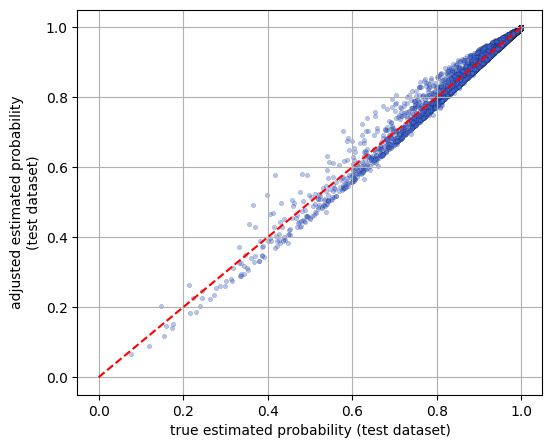

In [17]:
plt.figure(figsize=(6,5))
plt.scatter(prob_test, prob_test_1990, color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.4) 
plt.xlabel(f'true estimated probability (test dataset)')
plt.ylabel(f'adjusted estimated probability\n(test dataset)')
plt.grid(True)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.savefig('xgbc_method_COX_diagnoal_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

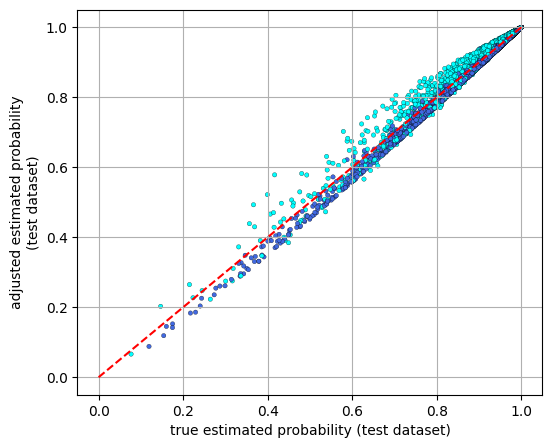

In [18]:
# convert to numpy arrays
prob_test = np.array(prob_test)
prob_test_1990 = np.array(prob_test_1990)
prob_test_cyan = np.array(prob_test_cyan)
prob_test_1990_cyan = np.array(prob_test_1990_cyan)

# combine all test points as pairs
all_points = np.array(list(zip(prob_test, prob_test_1990)))
cyan_points_set = set(zip(prob_test_cyan, prob_test_1990_cyan))

# create color list: pink if point is in red set, else blue
colors = ['cyan' if tuple(pt) in cyan_points_set else 'royalblue' for pt in all_points]
alpha = [1 if tuple(pt) in cyan_points_set else 1 for pt in all_points]
edgecolor = ['black' if tuple(pt) in cyan_points_set else 'black' for pt in all_points]
# --- plot ---
plt.figure(figsize=(6, 5))
plt.scatter(prob_test, prob_test_1990, c=colors, edgecolor=edgecolor, linewidths=0.2, s=10, alpha=alpha)
plt.xlabel('true estimated probability (test dataset)')
plt.ylabel('adjusted estimated probability\n(test dataset)')
plt.grid(True)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.savefig('xgbc_method_COX_diagnoal_test_extra.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

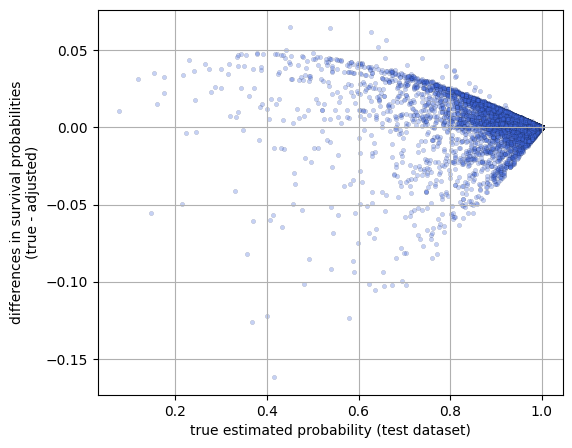

In [19]:
plt.figure(figsize=(6,5))
plt.scatter(prob_test, prob_test - prob_test_1990, color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.3)  
plt.xlabel('true estimated probability (test dataset)')
plt.ylabel(f'differences in survival probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('xgbc_method_COX_prob_differences_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

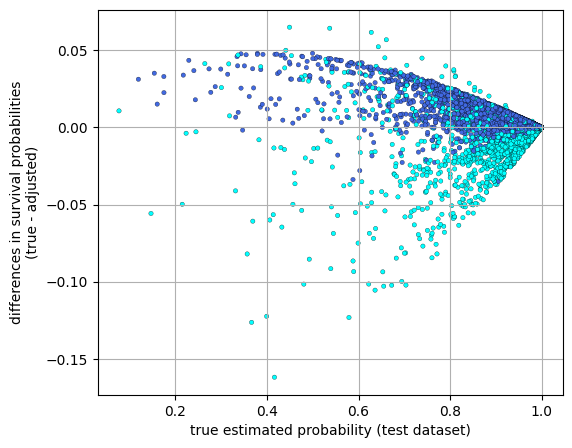

In [20]:
plt.figure(figsize=(6, 5))
plt.scatter(prob_test, prob_test - prob_test_1990, c=colors, edgecolor=edgecolor, linewidths=0.2, s=10, alpha=alpha)
plt.xlabel('true estimated probability (test dataset)')
plt.ylabel(f'differences in survival probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('xgbc_method_COX_prob_differences_test_extra.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

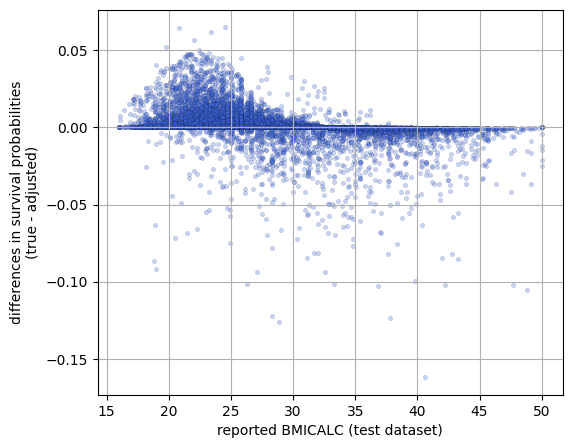

In [21]:
plt.figure(figsize=(6,5))
plt.scatter(df_test['BMICALC'], (prob_test- prob_test_1990), color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.3)  
plt.xlabel('reported BMICALC (test dataset)')
plt.ylabel(f'differences in survival probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('xgbc_method_COX_bmi_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

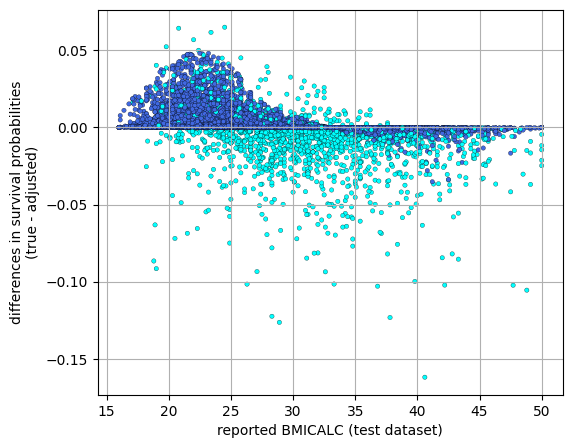

In [22]:
plt.figure(figsize=(6,5))
plt.scatter(df_test['BMICALC'], (prob_test- prob_test_1990), c=colors, edgecolor=edgecolor, linewidths=0.2, s=10, alpha=alpha)
plt.xlabel('reported BMICALC (test dataset)')
plt.ylabel(f'differences in survival probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('xgbc_method_COX_bmi_test_extra.png', format='png', dpi=300, bbox_inches='tight')
plt.show()